In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.combine import SMOTETomek

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [14]:
application_df = pd.read_csv("dataset/application_record.csv")
credit_df = pd.read_csv("dataset/credit_record.csv")

In [15]:
application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [16]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [17]:
print("Application Dataset:", application_df.shape)
print("Credit Dataset:", credit_df.shape)

Application Dataset: (438557, 18)
Credit Dataset: (1048575, 3)


Number of people working status:
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_2220\995899351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="OCCUPATION_TYPE", data=application_df, palette="Set2")


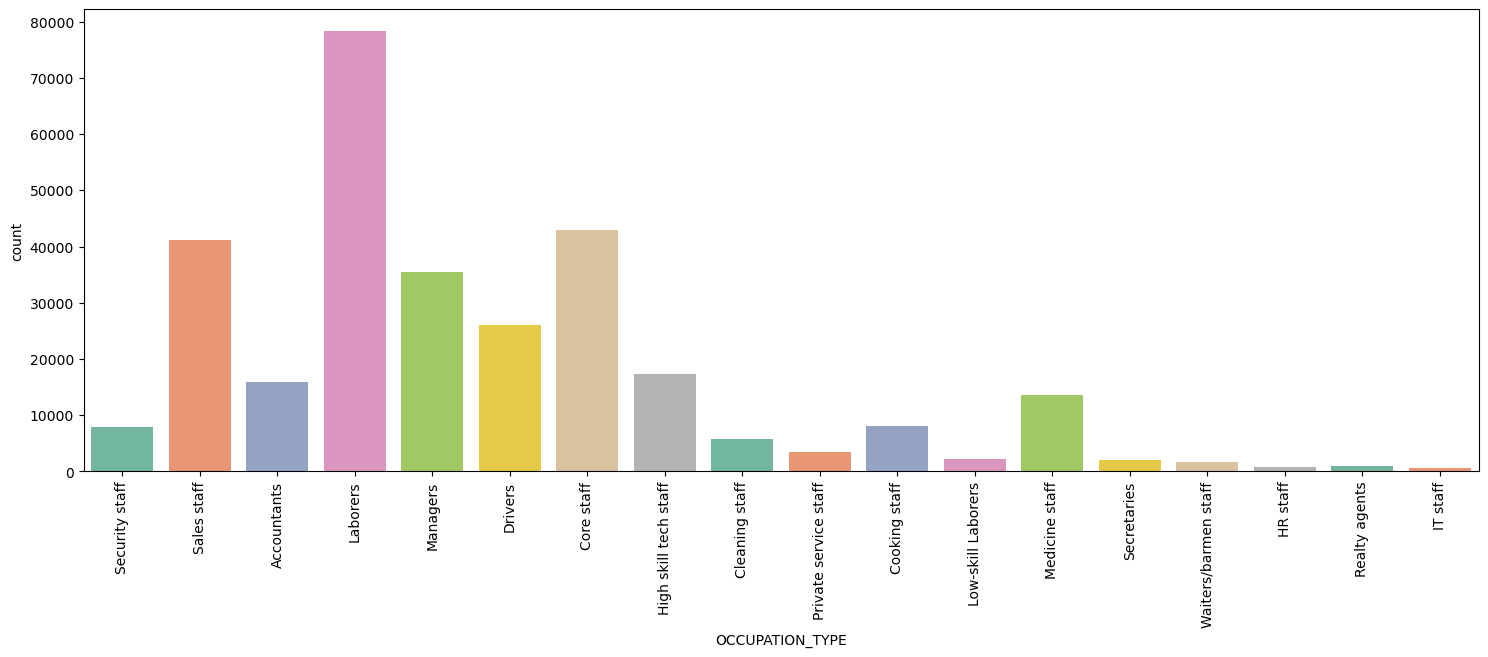

In [18]:
print("Number of people working status:")
print(application_df["OCCUPATION_TYPE"].value_counts())

plt.figure(figsize=(18,6))
sns.countplot(x="OCCUPATION_TYPE", data=application_df, palette="Set2")
plt.xticks(rotation=90)
plt.show()

In [19]:
application_df["AMT_INCOME_TOTAL"].describe()

count    4.385570e+05
mean     1.875243e+05
std      1.100869e+05
min      2.610000e+04
25%      1.215000e+05
50%      1.607805e+05
75%      2.250000e+05
max      6.750000e+06
Name: AMT_INCOME_TOTAL, dtype: float64

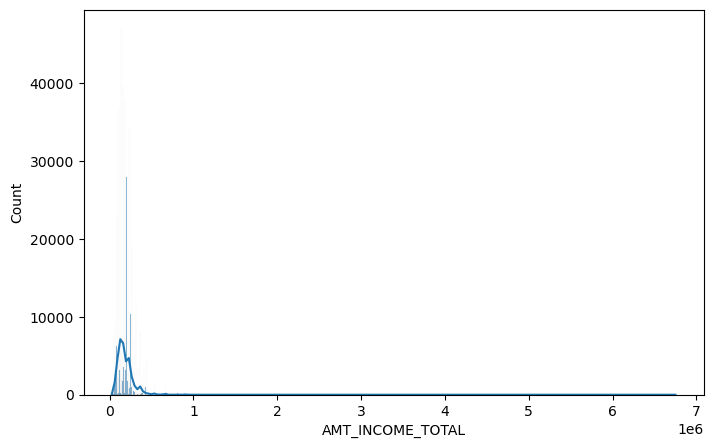

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(application_df["AMT_INCOME_TOTAL"], kde=True)
plt.show()

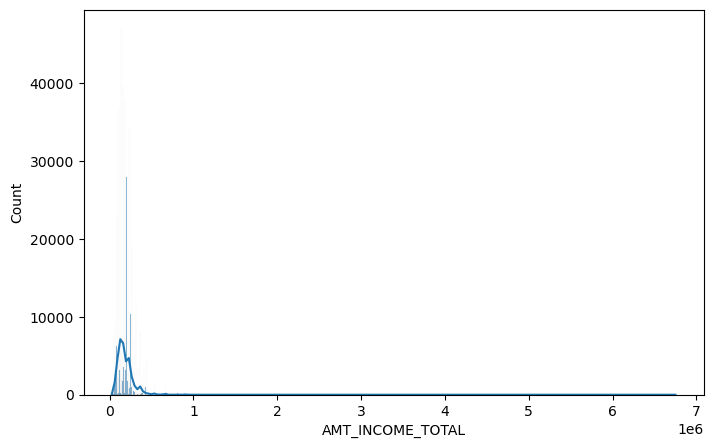

: 

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(application_df["AMT_INCOME_TOTAL"], kde=True)
plt.show()

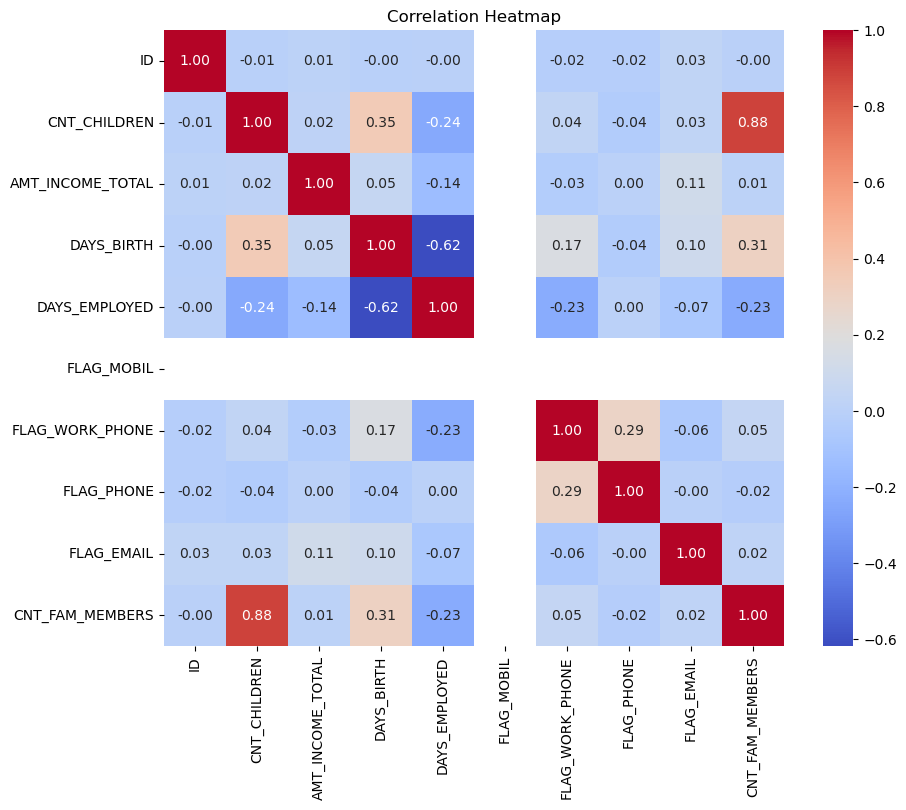

In [21]:
plt.figure(figsize=(10,8))

corr = application_df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [22]:
application_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [23]:
application_df.duplicated().sum()

0

In [24]:
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [25]:
application_df.isnull().mean() * 100

ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
DAYS_EMPLOYED           0.000000
FLAG_MOBIL              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
OCCUPATION_TYPE        30.601039
CNT_FAM_MEMBERS         0.000000
dtype: float64

In [26]:
application_df = application_df.drop(columns=['OCCUPATION_TYPE'])

In [27]:
application_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
CNT_FAM_MEMBERS        0
dtype: int64

In [28]:
application_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
CNT_FAM_MEMBERS        0
dtype: int64

In [29]:
application_df.shape

(438557, 17)

In [30]:
application_df.duplicated().sum()

0

In [31]:
application_df[['DAYS_BIRTH', 'DAYS_EMPLOYED']].head()

,DAYS_BIRTH,DAYS_EMPLOYED
0,-12005,-4542
1,-12005,-4542
2,-21474,-1134
3,-19110,-3051
4,-19110,-3051


In [32]:
application_df['DAYS_BIRTH'] = application_df['DAYS_BIRTH'].abs()
application_df['DAYS_EMPLOYED'] = application_df['DAYS_EMPLOYED'].abs()

In [33]:
application_df[['DAYS_BIRTH', 'DAYS_EMPLOYED']].head()

,DAYS_BIRTH,DAYS_EMPLOYED
0,12005,4542
1,12005,4542
2,21474,1134
3,19110,3051
4,19110,3051


In [34]:
credit_df['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [35]:
def to_binary(status):
    if status in ['0', 'X', 'C']:
        return 1
    else:
        return 0

In [36]:
credit_df['STATUS_BIN'] = credit_df['STATUS'].apply(to_binary)

In [37]:
credit_df['STATUS_BIN'].value_counts()

STATUS_BIN
1    1034381
0      14194
Name: count, dtype: int64

In [38]:
final_df = application_df.merge(
    credit_df,
    how='left',
    on='ID'
)

In [39]:
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,STATUS_BIN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,0.0,C,1.0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-1.0,C,1.0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-2.0,C,1.0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-3.0,C,1.0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,2.0,-4.0,C,1.0


In [40]:
final_df.isnull().sum().sort_values(ascending=False)

STATUS_BIN             402100
STATUS                 402100
MONTHS_BALANCE         402100
CODE_GENDER                 0
CNT_FAM_MEMBERS             0
FLAG_EMAIL                  0
FLAG_PHONE                  0
FLAG_WORK_PHONE             0
FLAG_MOBIL                  0
DAYS_EMPLOYED               0
ID                          0
NAME_HOUSING_TYPE           0
NAME_FAMILY_STATUS          0
NAME_EDUCATION_TYPE         0
NAME_INCOME_TYPE            0
AMT_INCOME_TOTAL            0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
FLAG_OWN_CAR                0
DAYS_BIRTH                  0
dtype: int64

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
application_df.select_dtypes(include='object').columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'],
      dtype='object')

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = application_df.select_dtypes(include='object').columns

for col in categorical_cols:
    application_df[col] = le.fit_transform(application_df[col].astype(str))

In [44]:
application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
0,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0
1,5008805,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0
2,5008806,1,1,1,0,112500.0,4,4,1,1,21474,1134,1,0,0,0,2.0
3,5008808,0,0,1,0,270000.0,0,4,3,1,19110,3051,1,0,1,1,1.0
4,5008809,0,0,1,0,270000.0,0,4,3,1,19110,3051,1,0,1,1,1.0


In [45]:
X = final_df.drop("STATUS_BIN", axis=1)
y = final_df["STATUS_BIN"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [48]:
X_train.select_dtypes(include='object').columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'STATUS'],
      dtype='object')

In [49]:
final_df.select_dtypes(include='object').columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'STATUS'],
      dtype='object')

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = final_df.select_dtypes(include='object').columns

for col in categorical_cols:
    final_df[col] = le.fit_transform(final_df[col].astype(str))


In [51]:
final_df.select_dtypes(include='object').columns


Index([], dtype='object')

In [52]:
X = final_df.drop("STATUS_BIN", axis=1)
y = final_df["STATUS_BIN"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
final_df.isnull().sum().sort_values(ascending=False)

STATUS_BIN             402100
MONTHS_BALANCE         402100
CODE_GENDER                 0
STATUS                      0
CNT_FAM_MEMBERS             0
FLAG_EMAIL                  0
FLAG_PHONE                  0
FLAG_WORK_PHONE             0
FLAG_MOBIL                  0
DAYS_EMPLOYED               0
ID                          0
NAME_HOUSING_TYPE           0
NAME_FAMILY_STATUS          0
NAME_EDUCATION_TYPE         0
NAME_INCOME_TYPE            0
AMT_INCOME_TOTAL            0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
FLAG_OWN_CAR                0
DAYS_BIRTH                  0
dtype: int64

In [55]:
final_df.shape

(1179815, 20)

In [56]:
final_df[['STATUS', 'STATUS_BIN', 'MONTHS_BALANCE']].head(20)

,STATUS,STATUS_BIN,MONTHS_BALANCE
0,6,1.0,0.0
1,6,1.0,-1.0
2,6,1.0,-2.0
3,6,1.0,-3.0
4,6,1.0,-4.0
5,6,1.0,-5.0
6,6,1.0,-6.0
7,6,1.0,-7.0
8,6,1.0,-8.0
9,6,1.0,-9.0


In [57]:
final_df = application_df.merge(credit_df, how='left', on='ID')

In [58]:
final_df[['STATUS_BIN', 'MONTHS_BALANCE']].isnull().sum()

STATUS_BIN        402100
MONTHS_BALANCE    402100
dtype: int64

In [59]:
final_df = final_df.dropna(subset=['STATUS_BIN'])

In [60]:
final_df[['STATUS_BIN', 'MONTHS_BALANCE']].isnull().sum()

STATUS_BIN        0
MONTHS_BALANCE    0
dtype: int64

In [61]:
X = final_df.drop(['STATUS', 'STATUS_BIN'], axis=1)
y = final_df['STATUS_BIN']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train model
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9853095285548048

Confusion Matrix
[[     0   2285]
 [     0 153258]]

Classification Report


c:\Users\Dell\Downloads\anconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\Downloads\anconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      2285
         1.0       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.49      0.50      0.50    155543
weighted avg       0.97      0.99      0.98    155543



c:\Users\Dell\Downloads\anconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
y.value_counts()

STATUS_BIN
1.0    766140
0.0     11575
Name: count, dtype: int64

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9868010775155424

Confusion Matrix
[[   891   1394]
 [   659 152599]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.57      0.39      0.46      2285
         1.0       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.78      0.69      0.73    155543
weighted avg       0.98      0.99      0.99    155543



In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9827700378673422

Confusion Matrix
[[   992   1293]
 [  1387 151871]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.42      0.43      0.43      2285
         1.0       0.99      0.99      0.99    153258

    accuracy                           0.98    155543
   macro avg       0.70      0.71      0.71    155543
weighted avg       0.98      0.98      0.98    155543



In [65]:
import joblib

joblib.dump(rf, "model.pkl")
print("Model Saved!")

Model Saved!


In [66]:
X.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE'],
      dtype='object')

In [67]:
print(le.classes_)

['0' '1' '2' '3' '4' '5' 'C' 'X' 'nan']


In [68]:
for col in [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]:
    print(col)
    print(application_df[col].unique())
    print("-"*40)

CODE_GENDER
[1 0]
----------------------------------------
FLAG_OWN_CAR
[1 0]
----------------------------------------
FLAG_OWN_REALTY
[1 0]
----------------------------------------
NAME_INCOME_TYPE
[4 0 1 2 3]
----------------------------------------
NAME_EDUCATION_TYPE
[1 4 2 3 0]
----------------------------------------
NAME_FAMILY_STATUS
[0 1 3 2 4]
----------------------------------------
NAME_HOUSING_TYPE
[4 1 2 5 0 3]
----------------------------------------


In [69]:
application_df[
    [
        "CODE_GENDER",
        "FLAG_OWN_CAR",
        "FLAG_OWN_REALTY",
        "NAME_INCOME_TYPE",
        "NAME_EDUCATION_TYPE",
        "NAME_FAMILY_STATUS",
        "NAME_HOUSING_TYPE"
    ]
].head(10)

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE
0,1,1,1,4,1,0,4
1,1,1,1,4,1,0,4
2,1,1,1,4,4,1,1
3,0,0,1,0,4,3,1
4,0,0,1,0,4,3,1
5,0,0,1,0,4,3,1
6,0,0,1,0,4,3,1
7,0,0,1,1,1,2,1
8,0,0,1,1,1,2,1
9,0,0,1,1,1,2,1


In [70]:
import pandas as pd

original_df = pd.read_csv("dataset/application_record.csv")

original_df[
[
"CODE_GENDER",
"FLAG_OWN_CAR",
"FLAG_OWN_REALTY",
"NAME_INCOME_TYPE",
"NAME_EDUCATION_TYPE",
"NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE"
]
].head(10)

original_df[
[
"CODE_GENDER",
"FLAG_OWN_CAR",
"FLAG_OWN_REALTY",
"NAME_INCOME_TYPE",
"NAME_EDUCATION_TYPE",
"NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE"
]
].head(10)

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE
0,M,Y,Y,Working,Higher education,Civil marriage,Rented apartment
1,M,Y,Y,Working,Higher education,Civil marriage,Rented apartment
2,M,Y,Y,Working,Secondary / secondary special,Married,House / apartment
3,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment
4,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment
5,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment
6,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment
7,F,N,Y,Pensioner,Higher education,Separated,House / apartment
8,F,N,Y,Pensioner,Higher education,Separated,House / apartment
9,F,N,Y,Pensioner,Higher education,Separated,House / apartment


In [71]:
print(original_df["NAME_INCOME_TYPE"].unique())
print(application_df["NAME_INCOME_TYPE"].unique())

['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']
[4 0 1 2 3]


In [72]:
print(original_df["NAME_EDUCATION_TYPE"].unique())
print(application_df["NAME_EDUCATION_TYPE"].unique())

['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
[1 4 2 3 0]


In [73]:
print(original_df["NAME_FAMILY_STATUS"].unique())
print(application_df["NAME_FAMILY_STATUS"].unique())

['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']
[0 1 3 2 4]


In [74]:
print(original_df["NAME_HOUSING_TYPE"].unique())
print(application_df["NAME_HOUSING_TYPE"].unique())

['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
[4 1 2 5 0 3]


In [72]:
from sklearn.model_selection import train_test_split

X = final_df.drop(["STATUS", "STATUS_BIN"], axis=1)
y = final_df["STATUS_BIN"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [76]:
print(X.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE']


In [77]:
len(rf.estimators_)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [77]:
len(rf.estimators_)

50

In [78]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [78]:
print(X_train.shape)

(622172, 18)


In [79]:
print(final_df["STATUS_BIN"].value_counts())

STATUS_BIN
1.0    766140
0.0     11575
Name: count, dtype: int64


In [80]:
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [82]:
import numpy as np

print(np.unique(y_pred))

[0. 1.]


In [83]:
## smote
!pip install imbalanced-learn

In [81]:
from imblearn.over_sampling import SMOTE

In [82]:
from sklearn.model_selection import train_test_split

X = final_df.drop("STATUS_BIN", axis=1)
y = final_df["STATUS_BIN"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

ValueError: could not convert string to float: 'C'

In [84]:
print(X_train.select_dtypes(include="object").columns)

Index(['STATUS'], dtype='object')


In [85]:
print(X_train.select_dtypes(include="object").head())

       STATUS
255599      C
537857      C
749728      0
112145      0
766365      C


In [86]:
print(X.columns)

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE', 'STATUS'],
      dtype='object')


In [87]:
print(X["STATUS"].value_counts())

STATUS
C    329536
0    290654
X    145950
1      8747
5      1527
2       801
3       286
4       214
Name: count, dtype: int64


In [88]:
X = X.drop("STATUS", axis=1)

In [89]:
print(X_train.select_dtypes(include="object").columns)

Index(['STATUS'], dtype='object')


In [90]:
print(X_train.select_dtypes(include="object").head())

       STATUS
255599      C
537857      C
749728      0
112145      0
766365      C


In [91]:
X = X.drop("STATUS", axis=1)

KeyError: "['STATUS'] not found in axis"

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [93]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [94]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [95]:
print(y_train_smote.value_counts())

STATUS_BIN
1.0    612912
0.0    612912
Name: count, dtype: int64


In [99]:
print("X_train exists:", "X_train" in globals())
print("X_train_smote exists:", "X_train_smote" in globals())
print("smote exists:", "smote" in globals())

X_train exists: True
X_train_smote exists: True
smote exists: True


In [97]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [98]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [96]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [10]:
print(rf)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)


In [11]:
print(hasattr(rf, "estimators_"))

False


In [110]:
y_pred = rf.predict(X_test)

In [111]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9648135885253596


In [112]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[  1294   1021]
 [  4452 148776]]


In [113]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.23      0.56      0.32      2315
         1.0       0.99      0.97      0.98    153228

    accuracy                           0.96    155543
   macro avg       0.61      0.76      0.65    155543
weighted avg       0.98      0.96      0.97    155543



In [114]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [115]:
print(final_df.shape)

(777715, 20)


In [4]:
%who

accuracy_score	 


In [2]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

NameError: name 'y_test' is not defined

In [3]:
print(X_train.shape)
print(X_train_smote.shape)

NameError: name 'X_train' is not defined

In [5]:
import os

size_mb = os.path.getsize("model.pkl") / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model size: 1178.56 MB


In [6]:
print(X_train.shape)
print(X_train_smote.shape)

NameError: name 'X_train' is not defined

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [101]:
y_pred = rf.predict(X_test)

In [102]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [103]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9229794976308802


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.12      0.65      0.20      2315
         1.0       0.99      0.93      0.96    153228

    accuracy                           0.92    155543
   macro avg       0.56      0.79      0.58    155543
weighted avg       0.98      0.92      0.95    155543



In [105]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[  1511    804]
 [ 11176 142052]]


In [106]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, prob))

ROC AUC: 0.8623644681218986


In [107]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[  1511    804]
 [ 11176 142052]]
